# [RSNA 2023 Abdominal Trauma Detection](https://www.kaggle.com/competitions/rsna-2023-abdominal-trauma-detection)

> Detect and classify traumatic abdominal injuries

![](https://www.kaggle.com/competitions/52254/images/header)

# 🧪 Experiment 2: `(ATD_EfficientNetB1_Model)`

* **ATD**= `Abdominal Trauma Detection`.
* **Simple** = Here it refer to experiment we will be conducting **without using any kind of data augmentation**.

## Step 1: Downloading And Extracting Data From Kaggle
🔑 **Note**: You will need your personal kaggle api key as kaggle.json that you can get on kaggle.

In [1]:
!mkdir ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [2]:
!kaggle datasets download -d jayantarsode/rsna-abdominal-trauma-subset

100% 6.54G/6.54G [04:21<00:00, 35.4MB/s]
100% 6.54G/6.54G [04:21<00:00, 26.8MB/s]


In [3]:
!unzip /content/rsna-abdominal-trauma-subset.zip

Streaming output truncated to the last 5000 lines.
  inflating: train_images/38150/25352/254.png  
  inflating: train_images/38150/25352/258.png  
  inflating: train_images/38150/25352/267.png  
  inflating: train_images/38150/25352/268.png  
  inflating: train_images/38150/25352/270.png  
  inflating: train_images/38150/25352/274.png  
  inflating: train_images/38150/25352/276.png  
  inflating: train_images/38150/25352/279.png  
  inflating: train_images/38150/25352/284.png  
  inflating: train_images/38150/25352/286.png  
  inflating: train_images/38150/25352/289.png  
  inflating: train_images/38150/25352/293.png  
  inflating: train_images/38150/25352/294.png  
  inflating: train_images/38150/25352/299.png  
  inflating: train_images/38150/25352/303.png  
  inflating: train_images/38150/25352/306.png  
  inflating: train_images/38150/25352/309.png  
  inflating: train_images/38150/25352/311.png  
  inflating: train_images/38150/25352/318.png  
  inflating: train_images/38150/25352

## Step 2: Installing Important Libraries

In [4]:
!pip install torchmetrics
!pip install wandb onnx -Uq

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 841.5/841.5 kB 12.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 41.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 823.6/823.6 kB 6.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.1/14.1 MB 85.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 731.7/731.7 MB 2.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 410.6/410.6 MB 3.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.6/121.6 MB 13.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.5/56.5 MB 28.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 124.2/124.2 MB 7.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 196.0/196.0 MB 4.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 166.0/166.0 MB 10.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.1/99.1 kB 14.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━

## Step 3: Setting Up Device We Will Work In.

In [5]:
import torch
device="cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [6]:
# Device configuration
if device=="cuda":
  !nvidia-smi
else:
  !cat /proc/cpuinfo

Fri Apr  5 12:02:30 2024       
+---------------------------------------------------------------------------------------+
| NVIDIA-SMI 535.104.05             Driver Version: 535.104.05   CUDA Version: 12.2     |
|-----------------------------------------+----------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |         Memory-Usage | GPU-Util  Compute M. |
|                                         |                      |               MIG M. |
|=========================================+======================+======================|
|   0  Tesla V100-SXM2-16GB           Off | 00000000:00:04.0 Off |                    0 |
| N/A   33C    P0              25W / 300W |      2MiB / 16384MiB |      0%      Default |
|                                         |                      |                  N/A |
+-----------------------------------------+----------------------+--

## Step 4: Importing and Using Our Custom Module [torch_helper_functions](https://drive.google.com/drive/folders/11e2iSHGQ9d-DeONfYe7nyY1v09IC1lFh?usp=sharing)

In [7]:
# Importing custom module
!unzip /content/torch_helper_functions_V1.zip

Archive:  /content/torch_helper_functions_V1.zip
  inflating: torch_helper_functions/plotting_utils.py  
  inflating: torch_helper_functions/multilabel/data_setup.py  
  inflating: torch_helper_functions/multilabel/train_engine.py  
  inflating: torch_helper_functions/utils.py  
  inflating: torch_helper_functions/multilabel/data_cleaner.py  


## Step 5: Importing the patients_with_abnormalities.csv that we got During [data cleaning and analysis](https://colab.research.google.com/drive/1RZLF4R20jLazr9NH_R4Yv6RIw7gZiB4e?usp=sharing).

In [8]:
# Importing train_valid_images.csv
import pandas as pd
patients_with_abnormalities=pd.read_csv('/content/patients_with_abnormalities.csv').drop(columns=['Unnamed: 0'])
patients_with_abnormalities.head()

,image_path,bowel_healthy,bowel_injury,extravasation_healthy,extravasation_injury,kidney_healthy,kidney_low,kidney_high,liver_healthy,liver_low,liver_high,spleen_healthy,spleen_low,spleen_high
0,/content/train_images/32982/5503/1000.png,1,0,1,0,1,0,0,1,0,0,0,1,0
1,/content/train_images/32982/5503/1001.png,1,0,1,0,1,0,0,1,0,0,0,1,0
2,/content/train_images/32982/5503/1002.png,1,0,1,0,1,0,0,1,0,0,0,1,0
3,/content/train_images/32982/5503/1003.png,1,0,1,0,1,0,0,1,0,0,0,1,0
4,/content/train_images/32982/5503/1004.png,1,0,1,0,1,0,0,1,0,0,0,1,0


In [9]:
patients_with_abnormalities['patient_id']=patients_with_abnormalities['image_path'].str.split('/').str[-3]
patients_with_abnormalities.head()

,image_path,bowel_healthy,bowel_injury,extravasation_healthy,extravasation_injury,kidney_healthy,kidney_low,kidney_high,liver_healthy,liver_low,liver_high,spleen_healthy,spleen_low,spleen_high,patient_id
0,/content/train_images/32982/5503/1000.png,1,0,1,0,1,0,0,1,0,0,0,1,0,32982
1,/content/train_images/32982/5503/1001.png,1,0,1,0,1,0,0,1,0,0,0,1,0,32982
2,/content/train_images/32982/5503/1002.png,1,0,1,0,1,0,0,1,0,0,0,1,0,32982
3,/content/train_images/32982/5503/1003.png,1,0,1,0,1,0,0,1,0,0,0,1,0,32982
4,/content/train_images/32982/5503/1004.png,1,0,1,0,1,0,0,1,0,0,0,1,0,32982


## Step 6: Setting Up Dataloaders for Training,Validation and Testing

In [10]:
# Importing important libraries
import warnings
warnings.filterwarnings('ignore')

In [11]:
# Label Columns to Select
label_columns = [ 'bowel_injury',
                  'extravasation_injury',
                  'kidney_healthy', 'kidney_low','kidney_high',
                  'liver_healthy', 'liver_low', 'liver_high',
                  'spleen_healthy', 'spleen_low', 'spleen_high']

In [12]:
from torch_helper_functions.multilabel import data_setup
import torch
from torchvision import transforms
from torchvision.transforms import v2
IMAGE_SIZE= 256
BATCH_SIZE = 32

custom_transform = v2.Compose([
    v2.Resize(size=(IMAGE_SIZE, IMAGE_SIZE), interpolation=3),  # Resize to desired size
    v2.RandomAffine(degrees=(-10, 10), translate=(0.05, 0.05), scale=(0.9, 1.1), shear=(-5, 5)),  # Adjust for medical images (consider reducing scale range)
    v2.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.1, hue=0.1),  # Adjust for medical images (lower values)
    v2.RandomApply([
        v2.GaussianBlur(kernel_size=(3, 3), sigma=(0.1, 0.5))
    ], p=0.2),
    v2.RandomErasing(p=0.1, scale=(0.02, 0.05), ratio=(0.3, 3.3), value=0),
    # Random grayscale after elastic transform (optional)
    v2.RandomGrayscale(p=0.1),

    v2.RandomApply([
        v2.ElasticTransform(alpha=0.2, sigma=0.1),  # Adjust for medical images (consider lower alpha)
    ], p=0.4),  # Apply with 40% probability
    v2.ToTensor()
])

val_transform = v2.Compose([
    v2.Resize(size=(IMAGE_SIZE, IMAGE_SIZE), interpolation=3),
    v2.ToTensor()
])

test_transform = v2.Compose([
    v2.Resize(size=(IMAGE_SIZE, IMAGE_SIZE), interpolation=3),
    v2.ToTensor()
])

# Loading the dataloader train,validation and test
train_dataloader, val_dataloader, test_dataloader, classes = data_setup.create_dataloaders_from_dataframe(patients_with_abnormalities,
                                                                                                         'image_path',
                                                                                                         label_columns,
                                                                                                         train_transform=custom_transform,
                                                                                                         val_transform=val_transform,
                                                                                                         test_transform=test_transform,
                                                                                                         batch_size=BATCH_SIZE,
                                                                                                         validation_split=0.15,
                                                                                                         test_split=0.15,
                                                                                                         channels=3)

Each 1 instance in dataloader=32 data points.
Train DataLoader contains: 1918 instance = 61353 data points.
Validation DataLoader contains: 339 instance = 10827 data points.
Test DataLoader contains: 399 instance = 12738 data points.


In [13]:
print(f"The labels in dataset are: \n{','.join(classes)}")

The labels in dataset are: 
bowel_injury,extravasation_injury,kidney_healthy,kidney_low,kidney_high,liver_healthy,liver_low,liver_high,spleen_healthy,spleen_low,spleen_high


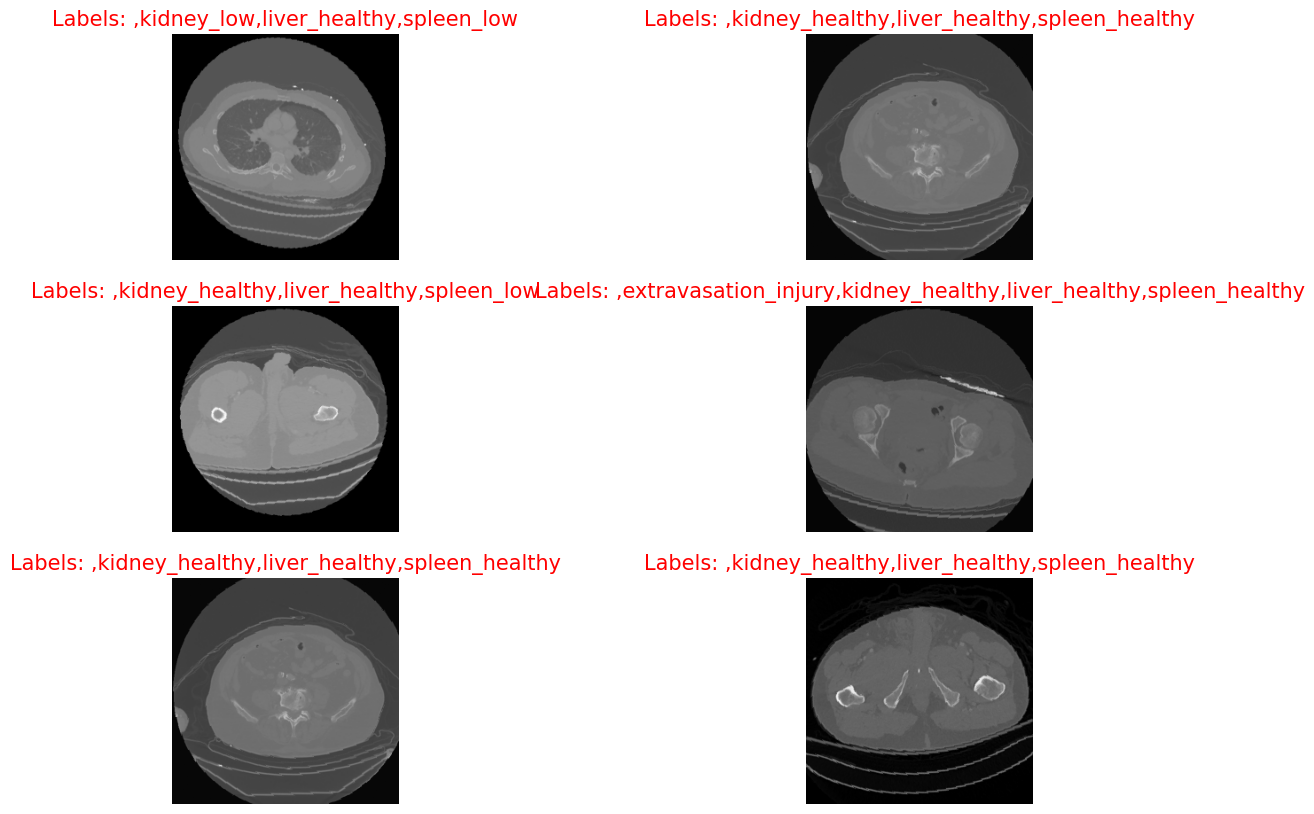

In [23]:
import random
import matplotlib.pyplot as plt
# Visualizing labels and images
images,y_bowel, y_extra, y_kidney, y_liver, y_spleen = next(iter(train_dataloader))
# Display sample data and labels
fig,ax = plt.subplots(3,2,figsize=(15,10))
ax = ax.ravel()
for k in range(6):
  label=''
  i = random.choice(range(0,31))
  ax[k].imshow(images[i].permute(1,2,0))
  if y_bowel[i].item()==1:
    label+=","+label_columns[0]
  if y_extra[i].item()==1:
    label+=","+label_columns[1]
  label+=","+label_columns[2+y_kidney[i].argmax()]
  label+=","+label_columns[5+y_liver[i].argmax()]
  label+=","+label_columns[8+y_spleen[i].argmax()]
  ax[k].set_title(f"Labels: {label}",c="r",fontsize=15)
  ax[k].axis("off")

## Step 7: Creating Our Model Architecture


In [15]:
!pip install efficientnet_pytorch

  Preparing metadata (setup.py) ... done
  Created wheel for efficientnet_pytorch: filename=efficientnet_pytorch-0.7.1-py3-none-any.whl size=16429 sha256=34290f00ce175e362f5c2850c5b4881fad2e0ef943b4db0b4661a62a5416ed83
  Stored in directory: /root/.cache/pip/wheels/03/3f/e9/911b1bc46869644912bda90a56bcf7b960f20b5187feea3baf
Successfully built efficientnet_pytorch


In [16]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from efficientnet_pytorch import EfficientNet

class ATD_EfficientNet(nn.Module):
    def __init__(self, input_shape=3, model_name='efficientnet-b1', num_blocks_to_unfreeze=0):
        super().__init__()
        self.effincentnet_base = EfficientNet.from_pretrained(model_name, in_channels=input_shape, image_size=[IMAGE_SIZE,IMAGE_SIZE]) # Assuming pretrained with ImageNet weights

        # Freeze all parameters of EfficientNet if pretrained is True
        for param in self.effincentnet_base.parameters():
            param.requires_grad = False

        # Unfreeze specific blocks of EfficientNet for fine-tuning
        if num_blocks_to_unfreeze > 0:
            for param in self.effincentnet_base._blocks[-num_blocks_to_unfreeze:].parameters():
                param.requires_grad = True

        num_features = self.effincentnet_base._fc.in_features  # Get the number of features from the last layer of EfficientNet
        self.flatten = nn.Flatten()  # Flatten the output of EfficientNet
        self.global_pooling = nn.AdaptiveAvgPool2d(1)  # Global average pooling

        self.bowel_head = nn.Sequential(
            nn.Linear(num_features, 32),
            nn.SiLU(),
            nn.Linear(32, 1)
        )

        self.extra_head = nn.Sequential(
            nn.Linear(num_features, 32),
            nn.SiLU(),
            nn.Linear(32, 1)
        )

        self.liver_head = nn.Sequential(
            nn.Linear(num_features, 64),
            nn.SiLU(),
            nn.Linear(64, 3)
        )

        self.kidney_head = nn.Sequential(
            nn.Linear(num_features, 64),
            nn.SiLU(),
            nn.Linear(64, 3)
        )

        self.spleen_head = nn.Sequential(
            nn.Linear(num_features, 64),
            nn.SiLU(),
            nn.Linear(64, 3)
        )

    def forward(self, x):
        x = self.flatten(self.global_pooling(self.effincentnet_base.extract_features(x)))
        bowel_out = self.bowel_head(x)
        extra_out = self.extra_head(x)
        kidney_out = self.kidney_head(x)
        liver_out = self.liver_head(x)
        spleen_out = self.spleen_head(x)
        return bowel_out, extra_out, kidney_out, liver_out, spleen_out

## Step 8: Instantiate Model And Getting Model Summary

In [17]:
# Install torchinfo, import if it's availabel
try:
  import torchinfo
except:
  !pip install torchinfo
  import torchinfo

In [18]:
torch.manual_seed(42)
INPUT_SHAPE=3
ATD_EfficientNetB1_Model = ATD_EfficientNet(input_shape=3, model_name='efficientnet-b1', num_blocks_to_unfreeze=4).to(device)

Downloading: "https://github.com/lukemelas/EfficientNet-PyTorch/releases/download/1.0/efficientnet-b1-f1951068.pth" to /root/.cache/torch/hub/checkpoints/efficientnet-b1-f1951068.pth
100%|██████████| 30.1M/30.1M [00:00<00:00, 316MB/s]


Loaded pretrained weights for efficientnet-b1


In [19]:
# Getting model architecture
from torchinfo import summary
# Print a summary using torchinfo (uncomment for actual output)
summary(model=ATD_EfficientNetB1_Model,
        input_size=[BATCH_SIZE,INPUT_SHAPE,IMAGE_SIZE,IMAGE_SIZE], # make sure this is "input_size", not "input_shape"
        # col_names=["input_size"], # uncomment for smaller output
        col_names=["input_size", "output_size", "num_params", "trainable"],
        col_width=20,
        row_settings=["var_names"]
)

Layer (type (var_name))                                           Input Shape          Output Shape         Param #              Trainable
ATD_EfficientNet (ATD_EfficientNet)                               [32, 3, 256, 256]    [32, 1]              --                   Partial
├─EfficientNet (effincentnet_base)                                --                   --                   1,281,000            Partial
│    └─Conv2dStaticSamePadding (_conv_stem)                       [32, 3, 256, 256]    [32, 32, 128, 128]   864                  False
│    │    └─ZeroPad2d (static_padding)                            [32, 3, 256, 256]    [32, 3, 257, 257]    --                   --
│    └─BatchNorm2d (_bn0)                                         [32, 32, 128, 128]   [32, 32, 128, 128]   (64)                 False
│    └─MemoryEfficientSwish (_swish)                              [32, 32, 128, 128]   [32, 32, 128, 128]   --                   --
│    └─ModuleList (_blocks)                          

### Step 8.1 Calculating class weights.
🔑 **Note**: We will be calculating class weigts due to more data imbalance as more patient are healthy and less have injuries.

In [24]:
def binary_class_weights(df,label):
  class_counts = df[label].value_counts()
  total_samples = len(df[label])
  class_weights = torch.tensor([total_samples / (len(class_counts) * count) for count in class_counts]).float()
  return class_weights.to(device)
class_weights_bowel=binary_class_weights(patients_with_abnormalities,label_columns[0])
class_weights_extra=binary_class_weights(patients_with_abnormalities,label_columns[1])
print(f"Class weights bowel: {class_weights_bowel}")
print(f"Class weights extravasation: {class_weights_extra}")

Class weights bowel: tensor([ 0.5065, 39.0967], device='cuda:0')
Class weights extravasation: tensor([0.5753, 3.8217], device='cuda:0')


In [25]:
def multiclass_class_weights(df,label):
    # Calculate class counts
    class_counts = df[label].sum(axis=0)

    # Calculate total samples
    total_samples = len(df[label])

    # Calculate class weights
    class_weights = torch.tensor([total_samples / count for count in class_counts]).float()

    return class_weights.to(device)
class_weights_kidney=multiclass_class_weights(patients_with_abnormalities,label_columns[2:5])
class_weights_liver=multiclass_class_weights(patients_with_abnormalities,label_columns[5:8])
class_weights_spleen=multiclass_class_weights(patients_with_abnormalities,label_columns[8:])
print(f"Class weights kidney: {class_weights_kidney}")
print(f"Class weights liver: {class_weights_liver}")
print(f"Class weights spleen: {class_weights_spleen}")

Class weights kidney: tensor([ 1.1534, 12.8352, 18.1604], device='cuda:0')
Class weights liver: tensor([ 1.2457,  6.4680, 23.4580], device='cuda:0')
Class weights spleen: tensor([ 1.2061,  9.0309, 16.6278], device='cuda:0')


## Step 9: Setting Up Hyperparameters And Loss,Metrics.

> **Loss Function** : [BCEWithLogitsLoss](https://pytorch.org/docs/stable/generated/torch.nn.BCEWithLogitsLoss.html),
[CROSSENTROPYLOSS](https://pytorch.org/docs/stable/generated/torch.nn.CrossEntropyLoss.html)

🔑 **Note**: We have two diffrent loss functions as metioned above.
  1. `BCEWithLogitsLoss -> For bowel,extravation.`
  2. `CROSSENTROPYLOSS -> For kidney,liver,spleen.`

> **Metrics For Evaluation**:
  1. `Accuracy Function`:
  * [torchmetrics.classification..BinaryAccuracy](https://lightning.ai/docs/torchmetrics/stable/classification/accuracy.html#binaryaccuracy)
  * [torchmetrics.classification.MulticlassAccuracy](https://lightning.ai/docs/torchmetrics/stable/classification/accuracy.html#multiclassaccuracy)

> **Optimizer**:
  1. [`AdamW.`](https://pytorch.org/docs/stable/generated/torch.optim.AdamW.html#torch.optim.AdamW)

🔑 **Note**: We have use diffrent learning rates for specific layers in the model.
 1. `base_efficentnet, 'lr': 0.0001`.
 2. `bowel_head, 'lr': 0.001`.
 3. `extra_head, 'lr': 0.001`.
 4. `kidney_head, 'lr': 0.001`.
 5. `liver_head, 'lr': 0.001`.
 6. `spleen_head, 'lr': 0.001`.

In [27]:
# Setting up loss functions with weights
criterion_bowel = nn.BCEWithLogitsLoss(pos_weight=torch.tensor([class_weights_bowel[1]]).to(device))
criterion_extra = nn.BCEWithLogitsLoss(pos_weight=torch.tensor([class_weights_extra[1]]).to(device))
criterion_kidney = nn.CrossEntropyLoss(weight=class_weights_kidney)
criterion_liver = nn.CrossEntropyLoss(weight=class_weights_liver)
criterion_spleen = nn.CrossEntropyLoss(weight=class_weights_spleen)


# Set different learning rates for different parts of the model
learning_rates = [
    {'params': ATD_EfficientNetB1_Model.effincentnet_base.parameters(), 'lr': 0.0001},  # Learning rate for EfficientNet base
    {'params': ATD_EfficientNetB1_Model.bowel_head.parameters(), 'lr': 0.001},
    {'params': ATD_EfficientNetB1_Model.extra_head.parameters(), 'lr': 0.001},
    {'params': ATD_EfficientNetB1_Model.kidney_head.parameters(), 'lr': 0.001},
    {'params': ATD_EfficientNetB1_Model.liver_head.parameters(), 'lr': 0.001},
    {'params': ATD_EfficientNetB1_Model.spleen_head.parameters(), 'lr': 0.001}
]
# Set up optimizer as AdamW
optimizer = torch.optim.AdamW(learning_rates)

# Setting up WandB init parameters
layer_list = list(ATD_EfficientNetB1_Model.named_children())
wandb_init_params = {
    'project': '7th_Sem_Major_Project',
    'experiment': 'ATD_EfficientNetB1_Model',
    'hyperparameters': {
        'learning_rate':0.0001,
        'optimizer': 'AdamW',
        'epochs': 20,
        'batch_size': 32
    }
}

## Step 10: Training And Validation Of Model

In [28]:
from torch_helper_functions.multilabel import train_engine

In [29]:
# Train for 20 epochs
torch.manual_seed(42)
torch.cuda.manual_seed(42)
# Number of epochs
EPOCHS = 20

ATD_EfficientNetB1_Model_history=train_engine.train(model=ATD_EfficientNetB1_Model,
                                                    train_dataloader=train_dataloader,
                                                    val_dataloader=val_dataloader,
                                                    optimizer=optimizer,
                                                    criterion_bowel=criterion_bowel,
                                                    criterion_extra=criterion_extra,
                                                    criterion_kidney=criterion_kidney,
                                                    criterion_liver=criterion_liver,
                                                    criterion_spleen=criterion_spleen,
                                                    wandb_init_params=wandb_init_params,
                                                    epochs=EPOCHS,
                                                    early_stopping={"patience": 5}
                                                    )

<IPython.core.display.Javascript object>

wandb: Logging into wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: You can find your API key in your browser here: https://wandb.ai/authorize
wandb: Paste an API key from your profile and hit enter, or press ctrl+c to quit:

 ··········


wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc


Epoch:   0%|          | 0/20 [00:00<?, ?it/s]

...

Epoch 19:
╒════════════╤═══════════╤══════════╤═══════════════╤══════════╤══════════╤══════════╕
│ Results    │      loss │    bowel │   extravation │   kidney │    liver │   spleen │
╞════════════╪═══════════╪══════════╪═══════════════╪══════════╪══════════╪══════════╡
│ Train      │ 0.0886003 │ 0.999756 │      0.99811  │ 0.995437 │ 0.989556 │ 0.99373  │
├────────────┼───────────┼──────────┼───────────────┼──────────┼──────────┼──────────┤
│ Validation │ 0.0161141 │ 1        │      0.999263 │ 0.999601 │ 0.999715 │ 0.998146 │
╘════════════╧═══════════╧══════════╧═══════════════╧══════════╧══════════╧══════════╛ 



Training:   0%|          | 0/1918 [00:00<?, ?it/s]

Validation:   0%|          | 0/339 [00:00<?, ?it/s]

Epoch 20:
╒════════════╤═══════════╤══════════╤═══════════════╤══════════╤══════════╤══════════╕
│ Results    │      loss │    bowel │   extravation │   kidney │    liver │   spleen │
╞════════════╪═══════════╪══════════╪═══════════════╪══════════╪══════════╪══════════╡
│ Train      │ 0.0850896 │ 0.999169 │      0.998273 │ 0.993355 │ 0.993841 │ 0.994238 │
├────────────┼───────────┼──────────┼───────────────┼──────────┼──────────┼──────────┤
│ Validation │ 0.0189364 │ 0.999816 │      0.999539 │ 0.996899 │ 0.999514 │ 0.999734 │
╘════════════╧═══════════╧══════════╧═══════════════╧══════════╧══════════╧══════════╛ 

Early stopping at epoch 20
Saving last epoch model
[INFO] Saving model to: ATD_EfficientNetB1_Model/epoch_20/ATD_EfficientNetB1_Model.pth
Saving last epoch model
[INFO] Saving model to: ATD_EfficientNetB1_Model/epoch_20/ATD_EfficientNetB1_Model.pth
Best validation loss: 0.012660198967754747 at epoch 15


early_stopping_epoch,▁
train_acc_bowel,▁▆▇▇▇█▇██████████████
train_acc_extra,▁▆▇▇▇████████████████
train_acc_kidney,▁▅▆▇▇▇▇██████████████
train_acc_liver,▁▅▆▇▇▇▇██████████████
train_acc_spleen,▁▅▆▇▇█▇██████████████
train_loss,█▃▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val_acc_bowel,▄▇▆▁█▇▇████▇▇████████
val_acc_extra,▁▇▇▇▇████████████████
val_acc_kidney,▁▆▇▆▇▆▇█▇████████████
val_acc_liver,▁▆▇▆▆▇█▇███▇█████████


## Step 11: Visualizing Training Curves

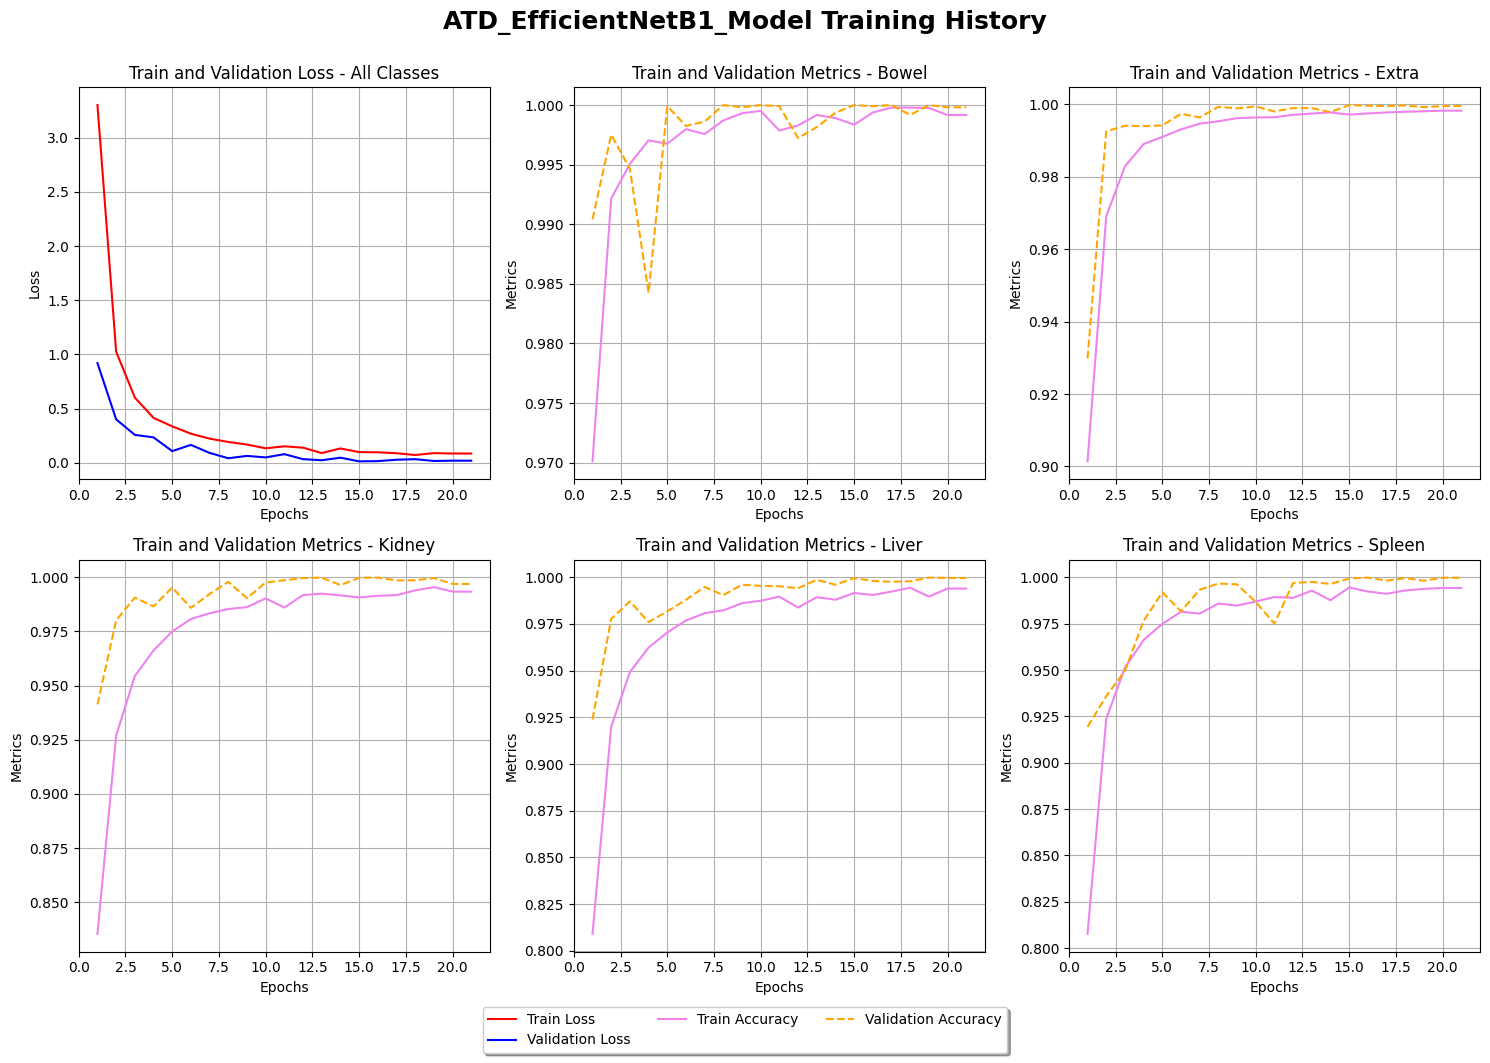

In [30]:
from torch_helper_functions import plotting_utils
plotting_utils.plot_model_history_curves(ATD_EfficientNetB1_Model_history)

## Step 12: Evaluating Trained Model On Test Data

In [31]:
from torch_helper_functions import utils
utils.model_evaluation(ATD_EfficientNetB1_Model,
                      dataloader=test_dataloader,
                      criterion_bowel=criterion_bowel,
                      criterion_extra=criterion_extra,
                      criterion_kidney=criterion_kidney,
                      criterion_liver=criterion_liver,
                      criterion_spleen=criterion_spleen)

Testing:   0%|          | 0/399 [00:00<?, ?it/s]

Test loss is: 0.0242
╒═══════════╤══════════╤═══════════════╤══════════╤══════════╤══════════╕
│ Results   │    bowel │   extravation │   kidney │    liver │   spleen │
╞═══════════╪══════════╪═══════════════╪══════════╪══════════╪══════════╡
│ Accuracy  │ 0.999765 │      0.999295 │ 0.991424 │ 0.999278 │ 0.998834 │
├───────────┼──────────┼───────────────┼──────────┼──────────┼──────────┤
│ F1_Score  │ 0.365414 │      0.984809 │ 0.985258 │ 0.999026 │ 0.997987 │
╘═══════════╧══════════╧═══════════════╧══════════╧══════════╧══════════╛ 



## Step 13: Plotting Confusion Matrix For All Labels

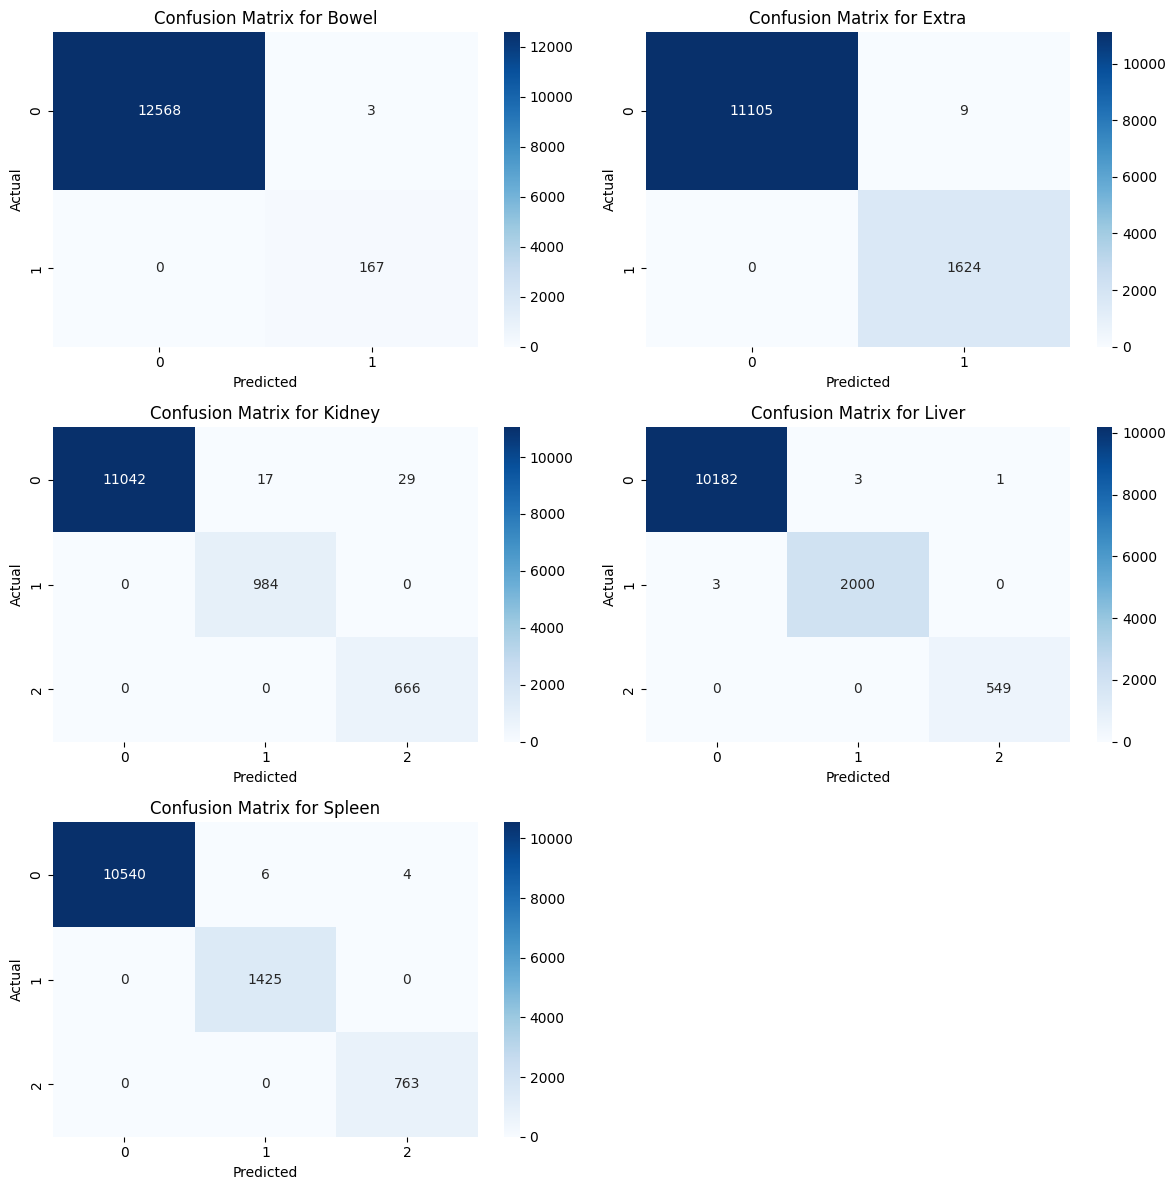

In [32]:
from torch_helper_functions import plotting_utils
plotting_utils.generate_confusion_matrix(ATD_EfficientNetB1_Model, test_dataloader)

## Step 14: Predicting Image Data With Our Model

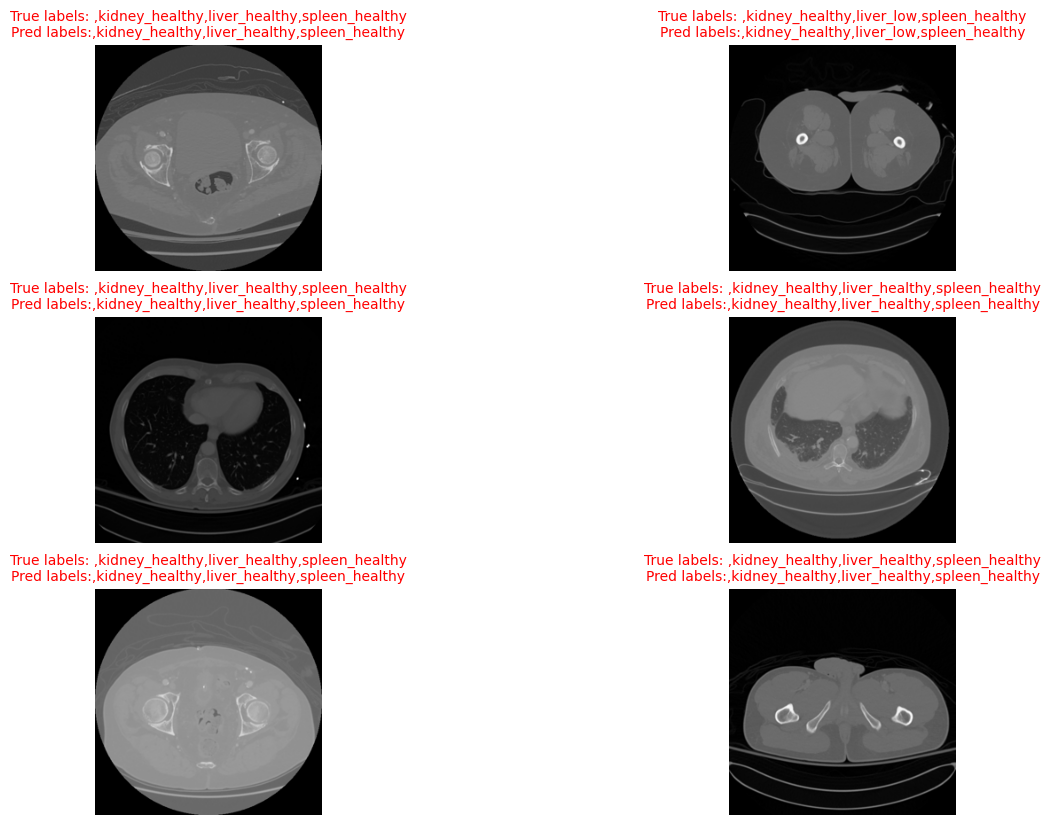

In [33]:
import random
import matplotlib.pyplot as plt
import numpy as np
import torch.nn.functional as F
ATD_EfficientNetB1_Model.eval()
# Visualizing labels and images
images,y_bowel, y_extra, y_kidney, y_liver, y_spleen = next(iter(test_dataloader))
# Forward pass
with torch.inference_mode():
  bowel_out, extra_out, kidney_out, liver_out, spleen_out = ATD_EfficientNetB1_Model(images.to(device))

# Convert logits to predictions
bowel_preds = (torch.sigmoid(bowel_out) > 0.5).int().cpu().numpy().flatten()
extra_preds = (torch.sigmoid(extra_out) > 0.5).int().cpu().numpy().flatten()
kidney_preds = np.argmax(F.softmax(kidney_out, dim=1).cpu().numpy(), axis=1).flatten()
liver_preds = np.argmax(F.softmax(liver_out, dim=1).cpu().numpy(), axis=1).flatten()
spleen_preds = np.argmax(F.softmax(spleen_out, dim=1).cpu().numpy(), axis=1).flatten()
# Display sample data and labels
fig,ax = plt.subplots(3,2,figsize=(15,10))
ax = ax.ravel()
for k in range(6):
  label=''
  pred_label=''
  i = random.choice(range(0,31))
  ax[k].imshow(images[i].permute(1,2,0),cmap="gray")
  if y_bowel[i].item()==1:
    label+=","+label_columns[0]
  if y_extra[i].item()==1:
    label+=","+label_columns[1]
  label+=","+label_columns[2+y_kidney[i].argmax()]
  label+=","+label_columns[5+y_liver[i].argmax()]
  label+=","+label_columns[8+y_spleen[i].argmax()]

  if bowel_preds[i].item()==1:
    pred_label+=","+label_columns[0]
  if extra_preds[i].item()==1:
    pred_label+=","+label_columns[1]
  pred_label+=","+label_columns[2+kidney_preds[i]]
  pred_label+=","+label_columns[5+liver_preds[i]]
  pred_label+=","+label_columns[8+spleen_preds[i]]
  ax[k].set_title(f"True labels: {label}\nPred labels:{pred_label}",fontsize=10,color="r")
  ax[k].axis("off")